# Monte Carlo Portfolio Optimization

###### By Fareeha A.

#### Project Overview
This project applies Monte Carlo simulation to optimize a three-asset portfolio of leading sector stocks: Apple, JPMorgan, and Exxon. By simulating 5,000 random portfolio weight combinations, the project visualizes the risk-return tradeoff across all possible allocations and approximates the Efficient Frontier.

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
%matplotlib inline

##### Data Collection

In [156]:
assets = ['AAPL', 'JPM', 'XOM']
pf_data = pd.DataFrame()

for a in assets:
    pf_data[a] = yf.download(a, start='2015-1-1', auto_adjust=False)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [157]:
pf_data.head()

,AAPL,JPM,XOM
Date,,,
2015-01-02,27.332500,62.490002,92.830002
2015-01-05,26.562500,60.549999,90.290001
2015-01-06,26.565001,58.980000,89.809998
2015-01-07,26.937500,59.070000,90.720001
2015-01-08,27.972500,60.389999,92.230003


In [158]:
log_returns = np.log(pf_data / pf_data.shift(1))
log_returns.head()

,AAPL,JPM,XOM
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.028576,-0.031537,-0.027743
2015-01-06,0.000094,-0.026271,-0.005330
2015-01-07,0.013925,0.001525,0.010082
2015-01-08,0.037703,0.022100,0.016508


In [159]:
num_assets = len(assets)
num_assets

3

In [160]:
weights = np.random.random(num_assets)
weights /= np.sum(weights)
print('Sample Weights:', weights)

Sample Weights: [0.24107737 0.28529615 0.47362648]


In [161]:
print('Weights Sum:', weights[0] + weights[1] + weights[2])

Weights Sum: 1.0


##### Expected Portfolio Return:

In [162]:
print('Expected Annual Return:', np.sum(weights * log_returns.mean()) * 250)

Expected Annual Return: 0.10865274198909011


##### Expected Portfolio Variance:

In [163]:
print('Expected Variance:', np.dot(weights.T, np.dot(log_returns.cov() * 250, weights)))

Expected Variance: 0.04793790761922034


##### Expected Portfolio Volatility:

In [164]:
print('Expected Volatility:', np.sqrt(np.dot(weights.T,np.dot(log_returns.cov() * 250, weights))))

Expected Volatility: 0.21894727132170508


##### Monte Carlo Simulation

In [165]:
pfolio_returns = []
pfolio_volatilities = []
pfolio_sharpe = []
pfolio_weights = []

for x in range(5000):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    
    ret = np.sum(weights * log_returns.mean()) * 250
    vol = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 250, weights)))
    sharpe = ret / vol
    
    pfolio_returns.append(ret)
    pfolio_volatilities.append(vol)
    pfolio_sharpe.append(sharpe)
    pfolio_weights.append(weights)

pfolio_returns = np.array(pfolio_returns)
pfolio_volatilities = np.array(pfolio_volatilities)
pfolio_sharpe = np.array(pfolio_sharpe)

##### Key Insights

In [166]:
portfolios = pd.DataFrame({
    'Return': pfolio_returns,
    'Volatility': pfolio_volatilities,
    'Sharpe Ratio': pfolio_sharpe
})

portfolios.head()
portfolios.describe()

# Key Portfolios Points
max_sharpe_idx = portfolios['Sharpe Ratio'].idxmax()
min_vol_idx = portfolios['Volatility'].idxmin()

max_sharpe_port = portfolios.iloc[max_sharpe_idx]
min_vol_port = portfolios.iloc[min_vol_idx]

print('Max Sharpe Ratio Portfolio:')
print(max_sharpe_port)
print('Minimum Variance Portfolio:')
print(min_vol_port)

Max Sharpe Ratio Portfolio:
Return          0.192357
Volatility      0.248969
Sharpe Ratio    0.772613
Name: 434, dtype: float64
Minimum Variance Portfolio:
Return          0.128712
Volatility      0.215642
Sharpe Ratio    0.596879
Name: 3752, dtype: float64


##### Efficient Frontier Scatter Plot

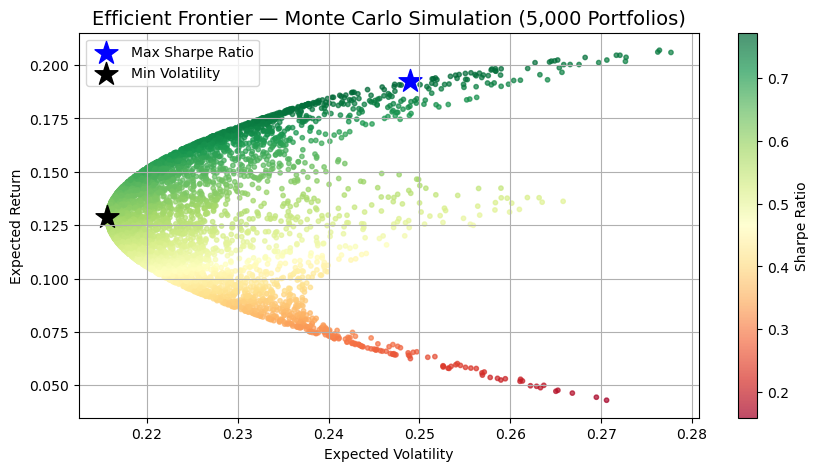

In [171]:
plt.figure(figsize=(10, 5))

scatter = plt.scatter(portfolios['Volatility'], portfolios['Return'],
                      c=portfolios['Sharpe Ratio'],
                      cmap='RdYlGn', s=10, alpha=0.7)

plt.colorbar(scatter, label='Sharpe Ratio')

# Max Sharpe Portfolio 
plt.scatter(max_sharpe_port['Volatility'], max_sharpe_port['Return'],
            color='blue', marker='*', s=300, label='Max Sharpe Ratio')

# Minimum Variance Portfolio
plt.scatter(min_vol_port['Volatility'], min_vol_port['Return'],
            color='black', marker='*', s=300, label='Min Volatility')

# Labels
plt.title('Efficient Frontier — Monte Carlo Simulation (5,000 Portfolios)', fontsize=14)
plt.xlabel('Expected Volatility')
plt.ylabel('Expected Return')
plt.legend()
plt.grid(True)
plt.show()